In [1]:
import pandas as pd
import numpy as np
import os
import ast
import umap

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score,f1_score
from astmhSupportFunctions_6april2024 import populateKeywordFeatureVector_fn
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from matplotlib.patches import Circle


In [2]:
root = '/home/ishan.shah/LLMForASTMH'
data_f = os.path.join(root, 'data')

df = pd.read_excel(os.path.join(data_f, 'train_split_1_41824.xlsx'), index_col=0)
df_test  = pd.read_excel(os.path.join(data_f, 'test_split_1_41824.xlsx'), index_col=0)



In [3]:
df24 = pd.read_excel(os.path.join(data_f, 'train_split_1_24.xlsx'), index_col=0)
df24_test  = pd.read_excel(os.path.join(data_f, 'test_split_1_24.xlsx'), index_col=0)

In [4]:
df.columns

Index(['abstractId', 'generalCategory', 'title', 'abstractText',
       'mergedCategory', 'category', 'shortGenCat', 'mergedCategory.1'],
      dtype='object')

In [5]:
kws_file = open(os.path.join(data_f, 'keywords_8april2024.txt'), 'r')
kws = kws_file.read()
 
kws_list = kws.split(',')
kws_list[-1] = kws_list[-1][:-1]
kws_list = list(set(kws_list))

In [6]:
df['kw_vector'] = df['abstractText'].apply(lambda x: populateKeywordFeatureVector_fn(x,
                                                                                     kws_list,
                                                                                     weights=[1, 0]))

df_test['kw_vector'] = df_test['abstractText'].apply(lambda x: populateKeywordFeatureVector_fn(x,
                                                                                     kws_list,
                                                                                     weights=[1, 0]))

In [7]:
# Initialize the vectorizer with the manually selected keywords
tfidf_vectorizer = TfidfVectorizer(vocabulary=kws_list)
# Generate the TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(df['abstractText'].tolist())
# Retrieve the feature names to ensure it's using only your keywords
feature_names = tfidf_vectorizer.get_feature_names_out()
# Convert the TF-IDF matrix to an array format for easier manipulation
tfidf_scores = tfidf_matrix.toarray()



tfidf_scores_test = tfidf_vectorizer.transform(df_test['abstractText'].tolist()).toarray()


/home/ishan.shah/anaconda3/envs/ave/lib/python3.8/site-packages/sklearn/feature_extraction/text.py:1322: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(


In [8]:
tfidf_scores.argmax

<function ndarray.argmax>

In [9]:
#np.load(os.path.join(data_f, 'all-mpnet-base-v1/split_1', 'train_embeddings_1.npy'))


In [10]:
new_cats = pd.read_excel(os.path.join(data_f, 'astmh2023AbstractContents_26mar2024.xlsx'), usecols=['abstractId', 'shortGenCat'])

In [11]:
#df = df.merge(new_cats, on='abstractId')
#df_test = df_test.merge(new_cats, on='abstractId')

def preprocess_df(df):
    green_gen_cats = ['Global Health', 'Malaria', 'One Health', 'Integrated Control']
    df['green_col'] = True
    df['importantCat'] = df['shortGenCat']
    df.loc[df['shortGenCat'].isin(green_gen_cats), 'green_col'] = False
    df.loc[~df['shortGenCat'].isin(green_gen_cats), 'importantCat'] = 'Other'
    return df

df = preprocess_df(df)
df_test = preprocess_df(df_test)

df24 = preprocess_df(df24)
df24_test = preprocess_df(df24_test)

# df_test['green_col'] = True

# df['importantCat'] = df['shortGenCat']
# df_test['importantCat'] = df_test['shortGenCat']

# df.loc[df['shortGenCat'].isin(green_gen_cats), 'green_col'] = False
# df_test.loc[df_test['shortGenCat'].isin(green_gen_cats), 'green_col'] = False

# df.loc[~df['shortGenCat'].isin(green_gen_cats), 'importantCat'] = 'Other'
# df_test.loc[~df_test['shortGenCat'].isin(green_gen_cats), 'importantCat'] = 'Other'

In [12]:
df_all = pd.concat([df, df_test])
df_all.reset_index(drop=True, inplace=True)

df_all24 = pd.concat([df24, df24_test])
df_all24.reset_index(drop=True, inplace=True)


In [13]:
df_all24['shortGenCat'].value_counts()

Malaria               446
Global Health         207
Integrated Control     76
One Health             43
Name: shortGenCat, dtype: int64

In [14]:
nn_preds_val = pd.read_excel('../results/avehjq8w/val_predictions.xlsx')
nn_preds_train = pd.read_excel('../results/avehjq8w/train_predictions.xlsx')
nn_preds_all = pd.concat([nn_preds_train, nn_preds_val])
nn_preds_correct = nn_preds_all[['abstractId', 'correct']]

In [15]:
nn_preds_24 = pd.read_excel('../results/4gsn8mi7/all_predictions.xlsx')[['abstractId','Predicted category: first choice']]
nn_preds_24.rename({'Predicted category: first choice' : '2024_Prediction'}, axis=1, inplace=True)
df_all24 = df_all24.merge(nn_preds_24, on='abstractId')


In [16]:
nn_preds_24.columns

Index(['abstractId', '2024_Prediction'], dtype='object')

In [17]:
df_all = df_all.merge(nn_preds_correct, on='abstractId')

In [18]:
#df_test['importantCat'].value_counts()

In [19]:
merged_to_short = dict(zip(df['mergedCategory'], df['shortGenCat']))

In [20]:
def parse_abstract_embedding(row):
    # Remove the brackets and newline characters
    s_clean = row.replace('[', '').replace(']', '').replace('\n', ' ')

    # Split the string by spaces, filter out empty strings, and convert to floats
    float_list = [float(num) for num in s_clean.split(' ') if num]

    # Optionally, convert the list to a numpy array
    float_array = np.array(float_list)
    return float_array

#df['abstract_embedding2'] = df['abstract_embedding'].apply(lambda x: parse_abstract_embedding(x))


In [21]:
INCLUDE_KEYWORDS = False
INCLUDE_KEYWORDS_TFIDF = False
emb_arr = np.load('/home/ishan.shah/LLMForASTMH/data/saved_embeddings/all-mpnet-base-v1/1_41824/train_N_o_n_e__embeddings.npy')
emb_arr_test = np.load('/home/ishan.shah/LLMForASTMH/data/saved_embeddings/all-mpnet-base-v1/1_41824/test_embeddings.npy')

emb_arr24 = np.load('/home/ishan.shah/LLMForASTMH/data/saved_embeddings/all-mpnet-base-v1/1_24/train____embeddings.npy')
emb_arr_test24 = np.load('/home/ishan.shah/LLMForASTMH/data/saved_embeddings/all-mpnet-base-v1/1_24/test_embeddings.npy')


if INCLUDE_KEYWORDS:
    emb_arr = np.concatenate((emb_arr, np.vstack(df['kw_vector'])), axis=1)
    emb_arr_test = np.concatenate((emb_arr_test, np.vstack(df_test['kw_vector'])), axis=1)
if INCLUDE_KEYWORDS_TFIDF:
    emb_arr = np.concatenate((emb_arr, tfidf_scores), axis=1)
    emb_arr_test = np.concatenate((emb_arr_test, tfidf_scores_test), axis=1)


all_embs= np.vstack([emb_arr, emb_arr_test])
all_embs24= np.vstack([emb_arr24, emb_arr_test24])



In [22]:
emb_arr.shape

(1822, 768)

In [23]:

#cat_col = 'category'
cat_col = 'shortGenCat'
#cat_col='mergedCategory'
#cat_col='importantCat'
y_train = df[cat_col].tolist()
y_test = df_test[cat_col].tolist()
y_all = df_all[cat_col].tolist()
# Initialize the UMAP reducer
reducer = umap.UMAP(n_neighbors=15, n_components=2, 
                    random_state=42,
                    metric='euclidean')

# Fit the model and transform the data to 2 dimensions
umap_embeddings = reducer.fit_transform(all_embs)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [24]:
umap_embeddings24 = reducer.transform(all_embs24)

In [25]:
X_train, X_test = emb_arr, emb_arr_test

In [26]:
X_train_24, X_test_24 = emb_arr24, emb_arr_test24

In [27]:
for c in range(umap_embeddings.shape[1]):
    df_all[f'umap{c+1}'] = umap_embeddings[:,c]
df_all['Year'] = 2023

for c in range(umap_embeddings.shape[1]):
    df_all24[f'umap{c+1}'] = umap_embeddings24[:,c]
df_all24['Year'] = 2024

df_both_years = pd.concat([df_all, df_all24])
df_both_years.sort_values(['shortGenCat'], inplace=True)
df_both_years.sort_values(['Year'], inplace=True, ascending=False)
df_both_years.reset_index(inplace=True, drop=True)

df_both_years.loc[df_both_years['Year'] == 2023, '2024_Prediction'] = df_both_years.loc[df_both_years['Year'] == 2023, 'shortGenCat']


In [28]:
df_both_years.groupby(['Year', '2024_Prediction']).size()

Year  2024_Prediction   
2023  Arthropods             29
      Bacteriology           95
      Cestodes               32
      Clinical Trop Med      81
      Ectoparasite-Borne     38
      Global Health         245
      HIV                    17
      Helminths              77
      Integrated Control     55
      Kinetoplastida         91
      Malaria               742
      Mosquitoes            257
      One Health             56
      Pneumonia TB           60
      Schistosomiasis        58
      Viruses               302
      Water Sanitation       43
2024  Arthropods              2
      Bacteriology           13
      Cestodes                1
      Clinical Trop Med      12
      Ectoparasite-Borne      5
      Global Health         128
      HIV                     1
      Helminths              10
      Integrated Control     40
      Kinetoplastida          3
      Malaria               463
      Mosquitoes             28
      One Health             24
      Pneumonia

In [29]:
#df_filt = df_all.groupby(['generalCategory']).filter(lambda x : len(x) >= 50)

In [30]:
green_gen_cats = ['Global Health', 'Malaria', 'One Health', 'Integrated Control']

df_filt = df_both_years.groupby(['generalCategory']).filter(
    lambda x: (len(x) >= 50) or (x.name in green_gen_cats)
)

In [31]:
df['importantCat'].value_counts()

Other                 944
Malaria               594
Global Health         195
One Health             45
Integrated Control     44
Name: importantCat, dtype: int64

In [32]:
df_filt['Year'].value_counts()

2023    2119
2024     772
Name: Year, dtype: int64

In [33]:
df_both_years.groupby(['Year', '2024_Prediction']).size()

Year  2024_Prediction   
2023  Arthropods             29
      Bacteriology           95
      Cestodes               32
      Clinical Trop Med      81
      Ectoparasite-Borne     38
      Global Health         245
      HIV                    17
      Helminths              77
      Integrated Control     55
      Kinetoplastida         91
      Malaria               742
      Mosquitoes            257
      One Health             56
      Pneumonia TB           60
      Schistosomiasis        58
      Viruses               302
      Water Sanitation       43
2024  Arthropods              2
      Bacteriology           13
      Cestodes                1
      Clinical Trop Med      12
      Ectoparasite-Borne      5
      Global Health         128
      HIV                     1
      Helminths              10
      Integrated Control     40
      Kinetoplastida          3
      Malaria               463
      Mosquitoes             28
      One Health             24
      Pneumonia

In [34]:
# Define your custom colors
highlight = {'Malaria': 'red', 
             'One Health': 'blue', 
             'Integrated Control': 'green', 
             'Global Health': '#C04000',
             'Viruses' : 'purple',
             'Mosquitoes' : 'pink'}
default_palette = sns.color_palette("husl", n_colors=len(df_both_years['shortGenCat'].unique()) - len(highlight))

# Construct the full palette
custom_palette = []
used = set(highlight.keys())
for category in df_both_years['shortGenCat'].unique():
    if category in highlight:
        custom_palette.append(highlight[category])
    else:
        custom_palette.append(default_palette.pop(0))
        
#color_mapping = dict(zip(categories, custom_palette))


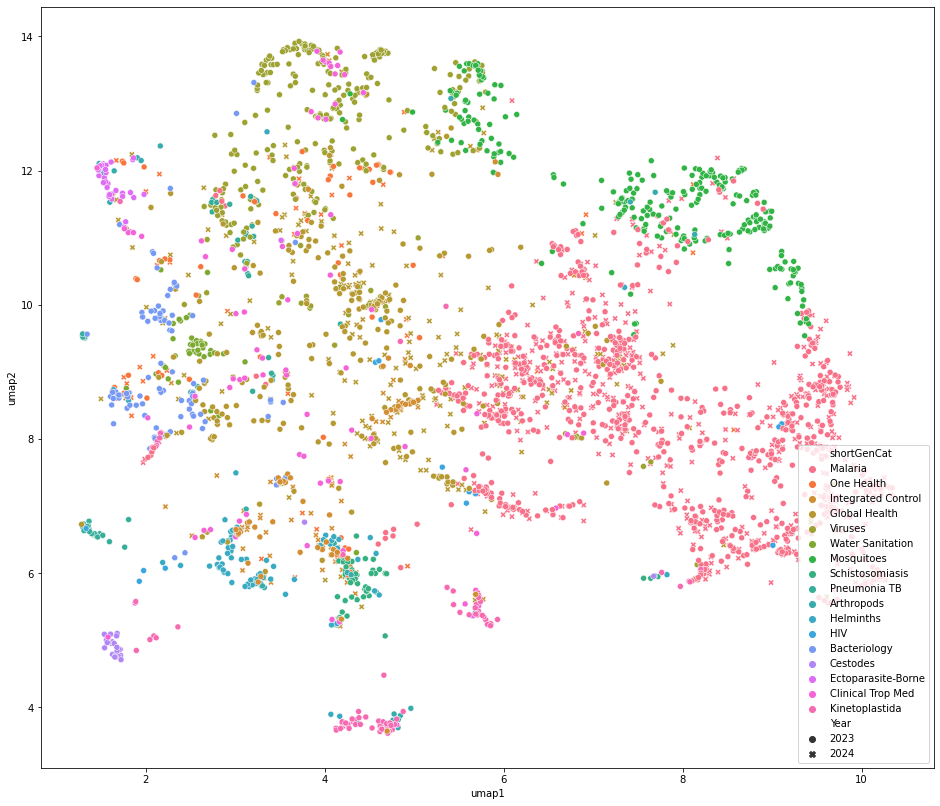

In [49]:

plt.figure(figsize=(16,14))
marker_dict = {True: 'o', False: 'x'}

# sns.scatterplot(x='umap1', y='umap2', 
#                 hue=cat_col,  # This should map to a categorical column for hue
#                 #style='green_col',  # This maps styles based on the boolean 'green_col'
#                 data=df_filt, 
#                 legend='brief',
#                 markers=['o' if i == True else 'x' for i in df_filt['green_col']])
PLOT_MISSED_PREDS = False
plot = sns.scatterplot(
    x='umap1',
    y='umap2',
    hue=cat_col,  # Column for hue
    style='Year', 
    data=df_both_years,
    legend='brief'
)


# Add a red circle around incorrect predictions
ax = plot.axes

if PLOT_MISSED_PREDS:
    for i, row in df_filt.iterrows():
        if not row['correct']:  # Check if the prediction was incorrect
            circle = Circle((row['umap1'], row['umap2']), 0.1, color='red', fill=False, linewidth=1)
            ax.add_patch(circle)

plt.legend(loc='lower right')
plt.show()


/tmp/ipykernel_308917/3993256031.py:14: UserWarning: The palette list has more values (17) than needed (6), which may not be intended.
  plot = sns.scatterplot(x='umap1', y='umap2',
/tmp/ipykernel_308917/3993256031.py:28: UserWarning: The palette list has more values (17) than needed (4), which may not be intended.
  plot2 = sns.scatterplot(x='umap1', y='umap2',
/tmp/ipykernel_308917/3993256031.py:38: UserWarning: The palette list has more values (17) than needed (4), which may not be intended.
  plot3 = sns.scatterplot(x='umap1', y='umap2',


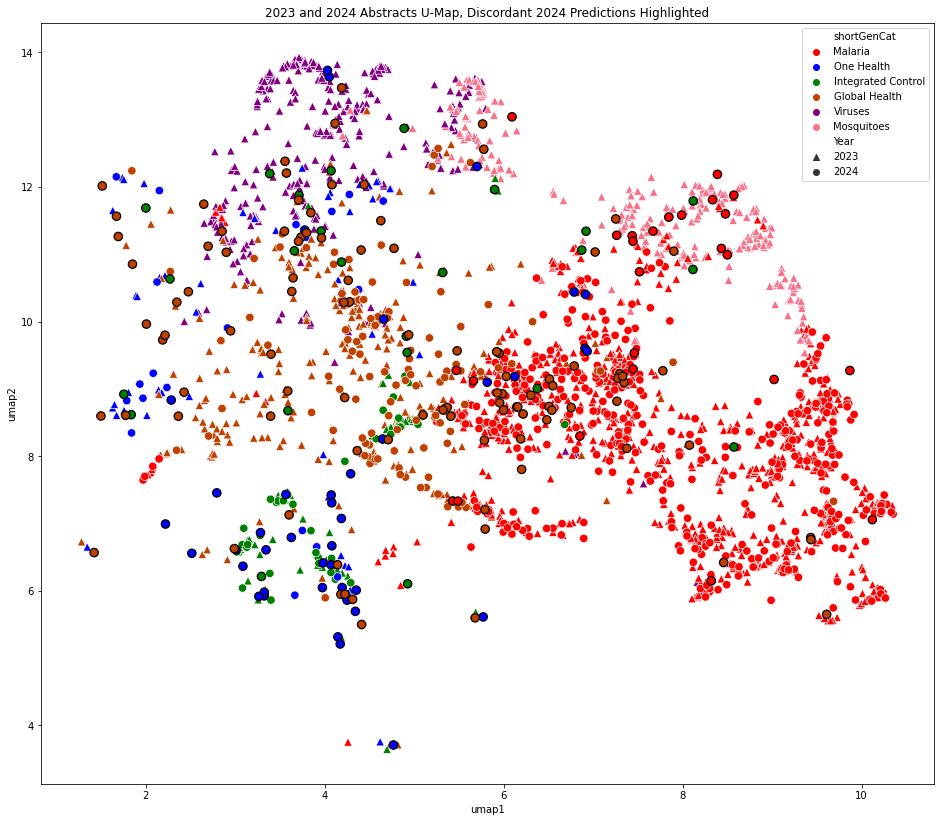

In [50]:

plt.figure(figsize=(16,14))
PLOT_MISSED_PREDS = True
GREEN_ONLY = True
PLOT_DIFFERENT_2024 = False
categories = df_both_years[cat_col].unique()
#palette = sns.color_palette('nipy_spectral', len(categories))
#color_mapping = dict(zip(categories, palette))
#COL_TO_USE = 'shortGenCat'
COL_TO_USE = 'shortGenCat'

marker_style = {2023: "^", 2024: "o"}

df_to_plot = df_both_years if not GREEN_ONLY else df_both_years[df_both_years[COL_TO_USE].isin(green_gen_cats + ['Viruses', 'Mosquitoes'])]
plot = sns.scatterplot(x='umap1', y='umap2', 
                hue=COL_TO_USE, 
                style='Year',
                markers=marker_style, 
                data=df_to_plot, 
                legend='brief', 
                palette=custom_palette,
                s=70)
                # s=50,
                # linewidth=0.8,
                # edgecolor="black")
                # s=80,  # Adjust size as needed
                # linewidth=1.5)  # Adjust line width to make the edges more prominent)
df_to_plot_24 = df_to_plot[df_to_plot['Year'] == 2024]
plot2 = sns.scatterplot(x='umap1', y='umap2', 
                hue=COL_TO_USE, 
                style='Year',
                markers=marker_style, 
                data=df_to_plot_24, 
                legend=None, 
                palette=custom_palette,
                s=70)

if PLOT_MISSED_PREDS:
    plot3 = sns.scatterplot(x='umap1', y='umap2', 
                    hue=COL_TO_USE, 
                    style='Year',
                    markers=marker_style, 
                    data=df_to_plot_24[df_to_plot_24['2024_Prediction'] != df_to_plot_24['shortGenCat']], 
                    legend=None, 
                    palette=custom_palette,
                    edgecolor='black',
                    linewidth=1.25,
                    s=70)
# Add a red circle around incorrect predictions
ax = plot.axes
# if PLOT_MISSED_PREDS:

#     for i, row in df_to_plot.iterrows():
#         if not row['correct']:  # Check if the prediction was incorrect
#             circle = Circle((row['umap1'], row['umap2']), 0.1, color='red', fill=False, linewidth=1)
#             ax.add_patch(circle)

if PLOT_DIFFERENT_2024:

    for i, row in df_to_plot_24.iterrows():
        if not row['2024_Prediction'] == row['shortGenCat']:  # Check if the prediction was incorrect
            circle = Circle((row['umap1'], row['umap2']), 0.07, color='black', fill=False, linewidth=1.5)
            ax.add_patch(circle)

plt.title("2023 and 2024 Abstracts U-Map, Discordant 2024 Predictions Highlighted")
plt.legend(loc='best')
plt.show()

/tmp/ipykernel_308917/3435302840.py:14: UserWarning: The palette list has more values (17) than needed (6), which may not be intended.
  plot = sns.scatterplot(x='umap1', y='umap2',
/tmp/ipykernel_308917/3435302840.py:25: UserWarning: The palette list has more values (17) than needed (6), which may not be intended.
  plot2 = sns.scatterplot(x='umap1', y='umap2',


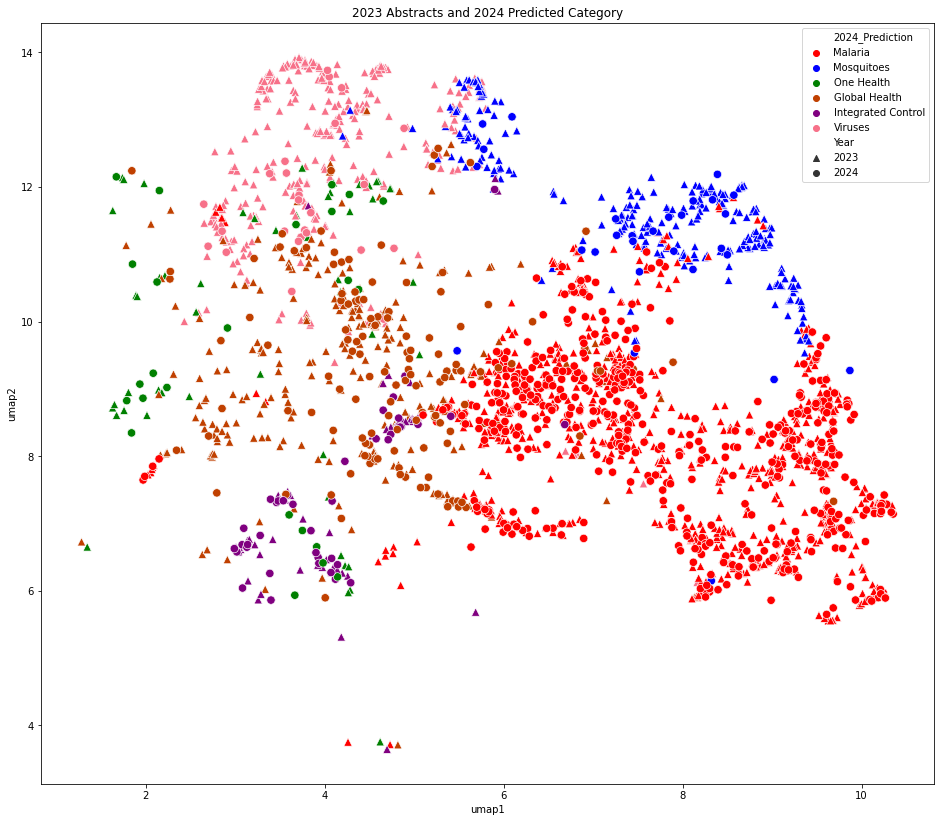

In [59]:

plt.figure(figsize=(16,14))
PLOT_MISSED_PREDS = False
GREEN_ONLY = True
PLOT_DIFFERENT_2024 = False
categories = df_both_years[cat_col].unique()
#palette = sns.color_palette('nipy_spectral', len(categories))
#color_mapping = dict(zip(categories, palette))
COL_TO_USE = '2024_Prediction'
#COL_TO_USE = '2024_Prediction'

marker_style = {2023: "^", 2024: "o"}

df_to_plot = df_both_years if not GREEN_ONLY else df_both_years[df_both_years[COL_TO_USE].isin(green_gen_cats + ['Viruses', 'Mosquitoes'])]
plot = sns.scatterplot(x='umap1', y='umap2', 
                hue=COL_TO_USE, 
                style='Year',
                markers=marker_style, 
                data=df_to_plot, 
                legend='brief', 
                palette=custom_palette,
                s=70)

df_to_plot_24 = df_to_plot[df_to_plot['Year'] == 2024]

plot2 = sns.scatterplot(x='umap1', y='umap2', 
                hue=COL_TO_USE, 
                style='Year',
                markers=marker_style, 
                data=df_to_plot_24, 
                legend=None, 
                palette=custom_palette,
                s=70)
                # s=50,
                # linewidth=0.8,
                # edgecolor="black")
                # s=80,  # Adjust size as needed
                # linewidth=1.5)  # Adjust line width to make the edges more prominent)

# Add a red circle around incorrect predictions
ax = plot.axes
if PLOT_MISSED_PREDS:

    for i, row in df_to_plot.iterrows():
        if not row['correct']:  # Check if the prediction was incorrect
            circle = Circle((row['umap1'], row['umap2']), 0.1, color='red', fill=False, linewidth=1)
            ax.add_patch(circle)

if PLOT_DIFFERENT_2024:

    for i, row in df_to_plot.iterrows():
        if not row['2024_Prediction'] == row['shortGenCat']:  # Check if the prediction was incorrect
            circle = Circle((row['umap1'], row['umap2']), 0.07, color='black', fill=False, linewidth=1.5)
            ax.add_patch(circle)

plt.title("2023 Abstracts and 2024 Predicted Category")
plt.legend(loc='best')
plt.show()

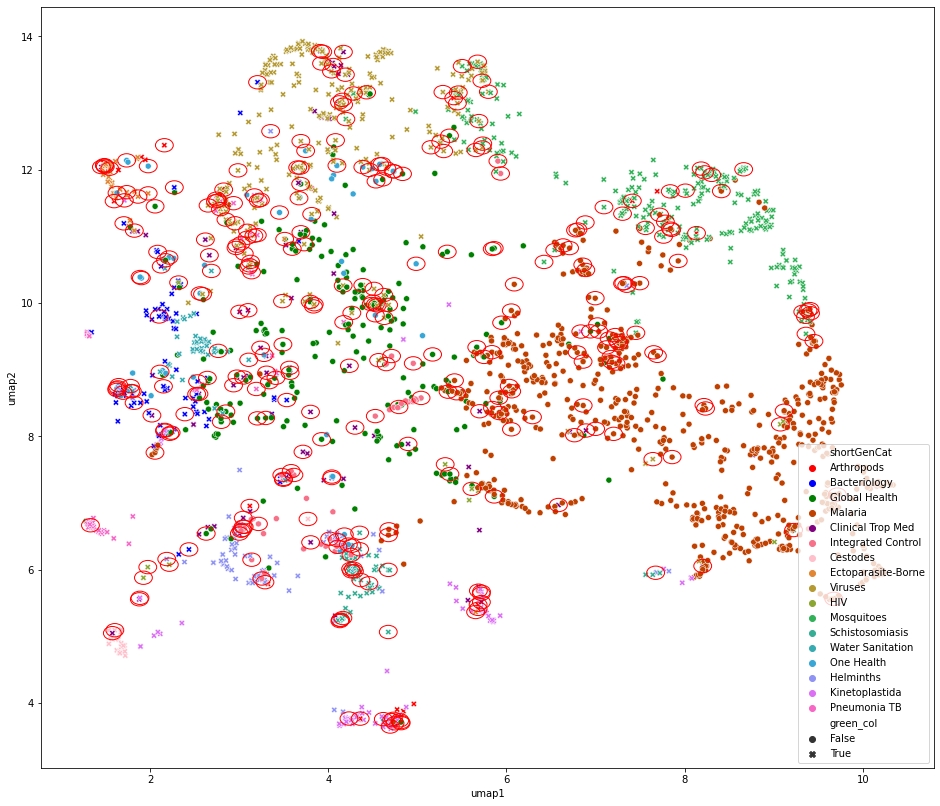

In [243]:

plt.figure(figsize=(16,14))

# categories = df_both_year[cat_col].unique()
# palette = sns.color_palette('nipy_spectral', len(categories))
# color_mapping = dict(zip(categories, palette))

plot = sns.scatterplot(x='umap1', y='umap2', 
                hue=cat_col, style='green_col', 
                data=df_all, legend='brief', 
                palette=custom_palette)
# Add a red circle around incorrect predictions
ax = plot.axes
for i, row in df_all.iterrows():
    if not row['correct']:  # Check if the prediction was incorrect
        circle = Circle((row['umap1'], row['umap2']), 0.1, color='red', fill=False, linewidth=1)
        ax.add_patch(circle)

plt.legend(loc='lower right')
plt.show()


In [72]:
df_all['shortGenCat'].unique()

array(['Arthropods', 'Bacteriology', 'Global Health', 'Malaria',
       'Clinical Trop Med', 'Integrated Control', 'Cestodes',
       'Ectoparasite-Borne', 'Viruses', 'HIV', 'Mosquitoes',
       'Schistosomiasis', 'Water Sanitation', 'One Health', 'Helminths',
       'Kinetoplastida', 'Pneumonia TB'], dtype=object)

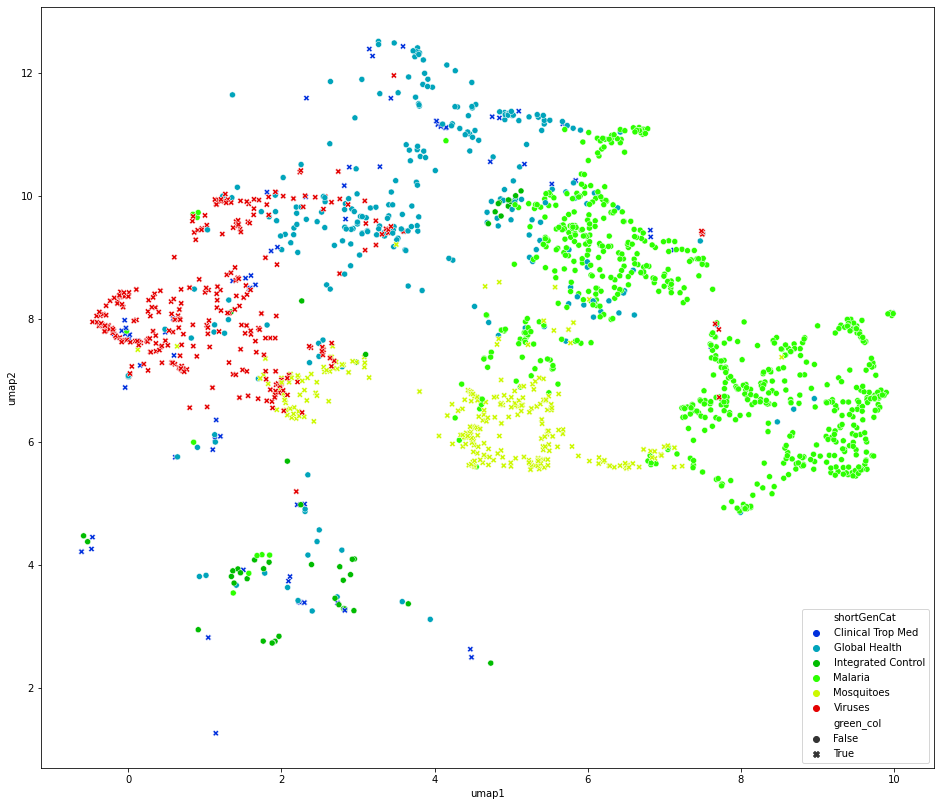

In [171]:

plt.figure(figsize=(16,14))

good_cats =['Malaria', 'Mosquitoes', 'Integrated Control', 'Global Health', 'Viruses', 'Clinical Trop Med']
df_filt2 = df_all.loc[df_all['shortGenCat'].isin(good_cats)]

sns.scatterplot(x='umap1', y='umap2', 
                hue=cat_col, style='green_col', 
                data=df_filt2, legend='brief', 
                palette=color_mapping)
plt.legend(loc='lower right')

### Non deep-learning modeling

In [74]:
svm_model = svm.SVC(kernel='linear', gamma=0.5, C=0.1)
svm_model.fit(emb_arr, y_train)

0
rf = RandomForestClassifier()
rf.fit(emb_arr, y_train)

RandomForestClassifier()

In [75]:
preds_test = svm_model.predict(emb_arr_test)
preds_test = rf.predict(emb_arr_test)

In [76]:
rbf_accuracy = accuracy_score(y_test, preds_test)
rbf_f1 = f1_score(y_test, preds_test, average='weighted')
print('Accuracy (RBF Kernel): ', "%.2f" % (rbf_accuracy*100))
print('F1 (RBF Kernel): ', "%.2f" % (rbf_f1*100))


Accuracy (RBF Kernel):  74.12
F1 (RBF Kernel):  69.98


In [77]:
df_test['preds_test'] = preds_test

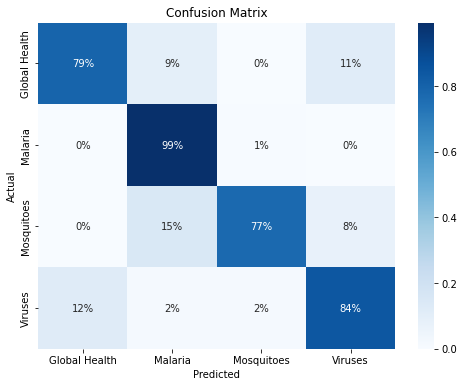

In [78]:
from sklearn.metrics import confusion_matrix

df_test_filt = df_test.groupby(['generalCategory']).filter(lambda x : len(x) >= 25)
# Calculate the confusion matrix

def confusion_map(df, preds_col, cat_col='shortGenCat', normalize=False):
    fig, ax = plt.subplots(figsize=(8, 6))

    if not normalize:
        conf_matrix = confusion_matrix(df[cat_col], df[preds_col], labels=pd.unique(df[cat_col]))
        # Plotting the confusion matrix
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=pd.unique(df[cat_col]), yticklabels=pd.unique(df[cat_col]))
    else:
                # Calculate the normalized confusion matrix (by the number of elements in each true class)
        conf_matrix_normalized = confusion_matrix(df[cat_col],  df[preds_col], normalize='true', labels=pd.unique(df[cat_col]))
        # Plotting the normalized confusion matrix
        sns.heatmap(conf_matrix_normalized, annot=True, fmt='.0%', cmap='Blues', xticklabels=pd.unique(df[cat_col]), yticklabels=pd.unique(df[cat_col]))
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

                
    
    
confusion_map(df_test_filt, 'preds_test', normalize=True)

In [79]:
shortgencat_weights = dict(zip(df['shortGenCat'].unique(), [1]*len(df['shortGenCat'].unique())))
new_weight = 50
for c in ['Global Health', 'Malaria', 'Integrated Control']:
    shortgencat_weights[c] = new_weight

In [80]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, make_scorer, precision_score

# Assuming X_train, y_train, X_holdout, y_holdout are already defined
# Define the parameter grid for RandomForestClassifier and SVC
# param_grid_rf = {
#     'n_estimators': [100, 200],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5]
# }
class_weights_other = {'Global Health': 10, 'Malaria': 10, 'One Health': 10, 'Other': 1}  # Increase weight for the specific classes to penalize their false positives more
class_weights_other2 = {'Global Health': 1, 'Malaria': 1, 'One Health': 1, 'Other': 10}  # Increase weight for the specific classes to penalize their false positives more

param_grid_rf = {
    'n_estimators': [200],
    'max_depth': [None],
    'min_samples_split': [2]
}


param_grid_svc = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']  # Relevant for 'rbf' kernel
}

def precision_for_class(y_true, y_pred):
    # Adjust based on how your classes are labeled; assuming here class 3 is labeled as "3"
    return precision_score(y_true, y_pred, labels=['Malaria'], average='macro')

custom_scorer = make_scorer(precision_for_class, greater_is_better=True)

#scorer = 'accuracy'
scorer = custom_scorer
# Initialize the classifiers
cw = class_weights_other2 if cat_col=='importantCat' else None
cw = shortgencat_weights if cat_col == 'shortGenCat' else None

rf = RandomForestClassifier(random_state=42, class_weight=cw)
svc = SVC(random_state=42, probability=True, class_weight=cw)


# Setup GridSearchCV for RandomForestClassifier
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search_svc = GridSearchCV(estimator=svc, param_grid=param_grid_svc, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Perform the grid search on the training data
print("Tuning Random Forest...")
grid_search_rf.fit(X_train, y_train)

print("Tuning SVM...")
grid_search_svc.fit(X_train, y_train)

# Retrieve the best estimators
best_rf = grid_search_rf.best_estimator_
best_svc = grid_search_svc.best_estimator_


Tuning Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Tuning SVM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [81]:
general_cats = df_test[cat_col].unique()

#cat_list = df_test[cat_col].unique().tolist()

cat_list = best_svc.classes_
# Evaluate on the holdout set
rf_predictions = best_rf.predict(X_test)
svc_predictions = best_svc.predict(X_test)
svm_arr = best_svc.predict_proba(X_test)
svc_predictions_by_prob = [cat_list[i] for i in svm_arr.argmax(axis=1)]

df_test['rf_preds'] = rf_predictions
df_test['svm_preds'] = svc_predictions
df_test['svm_preds_gen'] = [merged_to_short[i] for i in svc_predictions] if cat_col == 'mergedCat' else svc_predictions
y_test_gen = [merged_to_short[i] for i in y_test] if cat_col == 'mergedCat' else y_test
df_test['svm_preds_prob'] = svc_predictions_by_prob 

rf_accuracy = accuracy_score(y_test, rf_predictions)
svc_accuracy = accuracy_score(y_test, df_test['svm_preds'])
svc_accuracy_gen = accuracy_score(y_test_gen, df_test['svm_preds_gen'])
svc_accuracy_by_prob = accuracy_score(y_test, svc_predictions_by_prob)

print(f"Random Forest accuracy on holdout set ({cat_col}): {rf_accuracy:.4f}")
print(f"SVM accuracy on holdout set ({cat_col}): {svc_accuracy:.4f}")
print(f"SVM accuracy on holdout set (general category): {svc_accuracy_gen:.4f}")
print(f"SVM accuracy on holdout set (by probability): {svc_accuracy_by_prob:.4f}")

# You can also inspect the best parameters
print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best parameters for SVM:", grid_search_svc.best_params_)


Random Forest accuracy on holdout set (shortGenCat): 0.7346
SVM accuracy on holdout set (shortGenCat): 0.7873
SVM accuracy on holdout set (general category): 0.7873
SVM accuracy on holdout set (by probability): 0.7873
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [82]:
pd.Series(y_test) == 'Malaria'

0      False
1      False
2      False
3      False
4      False
       ...  
451    False
452    False
453    False
454    False
455    False
Length: 456, dtype: bool

In [83]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Assuming `y_test` are the true labels and `probabilities` are the softmax outputs from your model
# `class_index` is the index of your class of interest
target_class = 'Malaria'  # Change this to your class of interest's index
class_index = list(cat_list).index(target_class)

def pr_curve_astmh(y_true, target_class, class_index, scores_array):
    y_true_binary = (pd.Series(y_true) == target_class).astype(int)
    count_target = np.sum(y_true_binary)
    y_scores = scores_array[:, class_index]

    precision, recall, thresholds = precision_recall_curve(y_true_binary, y_scores)

    # Append maximum precision and recall to handle the last threshold
    precision = np.append(precision, 1)
    recall = np.append(recall, 0)

    # Create a PR curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label='PR Curve')

    # Annotate specific thresholds [0.1, 0.2, ..., 1.0]
    for threshold in np.arange(0.1, 1.1, 0.1):
        # Find the closest threshold index
        idx = np.argmin(np.abs(thresholds - threshold))
        plt.scatter(recall[idx], precision[idx], marker='o')  # Mark the point on the curve
        plt.annotate(f'{threshold:.2f}', (recall[idx], precision[idx]), 
                    textcoords="offset points", xytext=(0,10), ha='center')

    plt.title(f'Precision-Recall curve for class {target_class}, n = {count_target}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    plt.show()


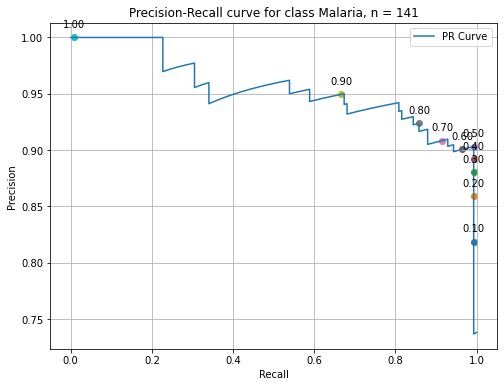

In [84]:
pr_curve_astmh(y_true=y_test, target_class='Malaria', 
                        class_index=list(cat_list).index(target_class), 
                        scores_array=svm_arr)

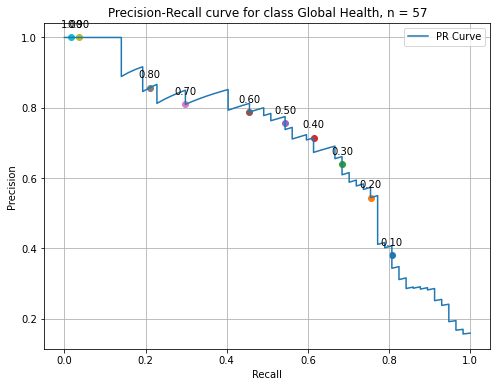

In [85]:
target_class='Global Health'
pr_curve_astmh(y_true=y_test, target_class=target_class, 
                        class_index=list(cat_list).index(target_class), 
                        scores_array=svm_arr)

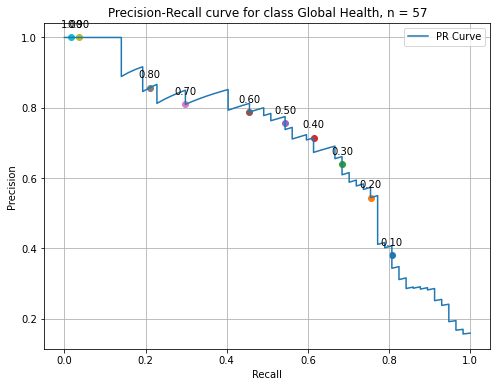

In [86]:
target_class='Global Health'
pr_curve_astmh(y_true=y_test, target_class=target_class, 
                        class_index=list(cat_list).index(target_class), 
                        scores_array=svm_arr)

In [87]:
len(df_test.loc[df_test['svm_preds_prob'] != df_test['svm_preds']])

11

In [88]:
mosq_as_mal = df_test.query("generalCategory == 'Mosquitoes' and svm_preds == 'Malaria'")
mm_arr = svm_arr[mosq_as_mal.index, :]


In [89]:
mosq_as_mal['abstractText'].tolist()[3]

"The control of malaria is still heavily dependent on mosquito control interventions. With progress in malaria control stalling in recent years, it is essential to understand the impact of interventions on vector populations. Age grading is a valuable method for determining whether interventions alter the age structure of target mosquito populations, but current methodologies are logistically challenging to incorporate into clinical trials and routine surveillance. We validated a method for dry preserving mosquitoes using silica gel and rehydrating prior to parity assessment using the ovarian tracheation method. Lab-reared Anopheles coluzzii mosquitoes with known parity-status were dry-preserved in silica gel for 1, 2, 6, 9 and 12 weeks, and rehydrated prior to parity assessment. Results were compared to parity results from freshly-killed mosquitoes from the same colony. Following lab validation, field-caught An. gambiae s.l. from the Bijagós Archipelago, Guinea-Bissau, were assessed b

In [90]:
wrong_malaria = df_test.query("generalCategory not in ('Malaria', 'Mosquitoes') and svm_preds == 'Malaria'")
wrong_malaria['abstractText'].tolist()[0]

'In Plasmodium falciparum holoendemic transmission regions such as Siaya, Kenya, clinical malaria can be accompanied by concurrent bacteremia. The primary manifestation of severe malaria in children <5 years in such regions is severe malarial anemia [SMA, hemoglobin (Hb)≤6.0g/dL]. In a cohort of children in Siaya (n=585), we showed that malaria and bacteremia co-infections can result in higher rates of anemia than witnessed in mono-infections. To further characterize the influence of malaria and bacteremia co-infection on clinical outcomes, we performed combined analyses in three cohorts of children (aged <5 years) presenting at Siaya County Referral Hospital with acute malaria: cohort 1 (n=783; 3/2004 to 12/2005), cohort 2 (n=876; 2/2009 to 12/2012), and cohort 3 (n=752; 3/2017 to 5/2022) for a total of 2,411 children. The prevalence of malaria in the combined cohorts was 68.4%, with 23.8% of the cases being SMA. The prevalence of bacteremia was 5.6%: 4.1% Gram(-) and 1.5% Gram(+). Th

In [91]:
#mosq_as_mal['abstractText'][329]

In [92]:
# fig, axs = plt.subplots(4, 1, figsize=(7.5, 10))

# for i in range(4):
#     axs[i].bar(df_test['shortGenCat'].unique(), mm_arr[i, :])
#     axs[i].set_title(f'Barplot {i+1}')
#     axs[i].tick_params(axis='x', rotation=45)
#     axs[i].set_ylabel('Value')
#     axs[i].set_ylim(0, 1)  # Adjust based on your data's range

# plt.tight_layout()
# plt.show()

/tmp/ipykernel_1435251/1530204208.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mosq['agreement'] = df_mosq.apply(lambda row: 'correct' if row['shortGenCat'] == row['svm_preds_gen'] else 'wrong', axis=1)


Text(0, 0.5, 'Mosquito Score')

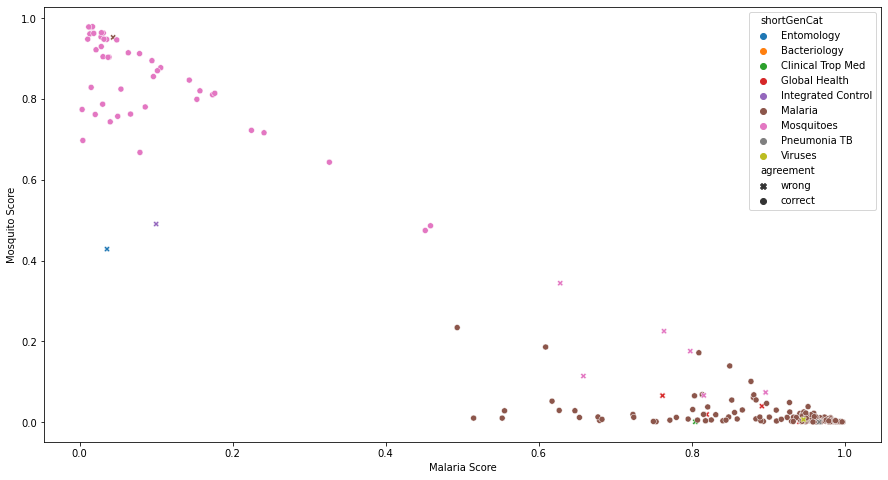

In [93]:
fig, ax = plt.subplots(figsize=(15, 8))
df_mosq = df_test.query("svm_preds in ('Malaria', 'Mosquitoes')")
df_mosq['agreement'] = df_mosq.apply(lambda row: 'correct' if row['shortGenCat'] == row['svm_preds_gen'] else 'wrong', axis=1)

sns.scatterplot(x=svm_arr[df_mosq.index,10], 
                y=svm_arr[df_mosq.index,11],
                hue=df_mosq['shortGenCat'], 
                style=df_mosq['agreement'],
                markers={'correct' : 'o', 'wrong' : 'X'}
                )
plt.xlabel('Malaria Score')
plt.ylabel('Mosquito Score')

In [94]:
missed_malaria = df_test.loc[(df_test['svm_preds'] == 'Malaria') & (df_test['generalCategory'] != 'Malaria')]

In [95]:
svm_arr[missed_malaria.index, :].argmax(axis=1)

array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10])

In [96]:
svm_arr[missed_malaria.index[1], :]#.argmax(axis=1)

array([1.25317851e-03, 3.11643728e-04, 2.09903246e-02, 4.97231845e-04,
       3.57453446e-04, 1.52107055e-01, 7.80357931e-04, 1.05576784e-03,
       8.38052433e-03, 2.25281027e-03, 8.04660954e-01, 1.04195304e-03,
       1.06459386e-03, 1.58735791e-03, 2.36205909e-04, 2.75392427e-03,
       6.68662857e-04])

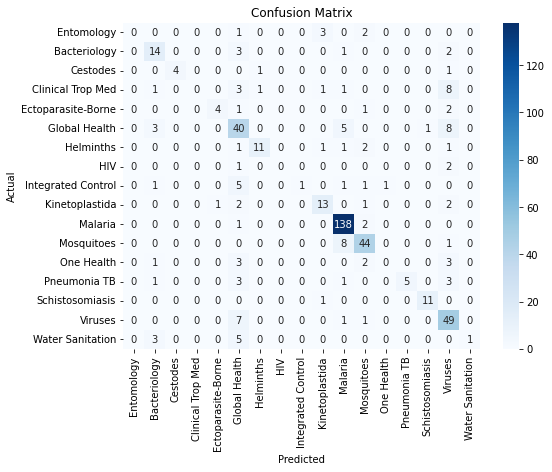

In [97]:
confusion_map(df_test, 'rf_preds', cat_col)

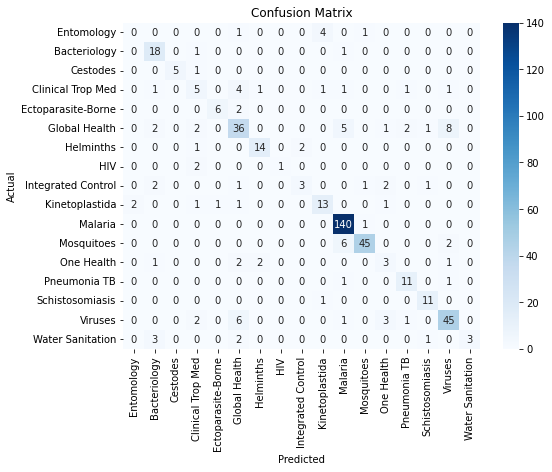

In [98]:

confusion_map(df_test, 'svm_preds_gen', cat_col)

In [441]:
fp_malaria_df = df_test.loc[(df_test['svm_preds_gen'] == 'Malaria') & (df_test[cat_col] != 'Malaria')]
fp_malaria_arr = svm_arr[fp_malaria_df.index]


In [442]:
best_svc.classes_

array(['Bacteriology', 'Cestodes', 'Clinical Trop Med',
       'Ectoparasite-Borne', 'Entomology', 'Global Health', 'HIV',
       'Helminths', 'Integrated Control', 'Kinetoplastida', 'Malaria',
       'Mosquitoes', 'One Health', 'Pneumonia TB', 'Schistosomiasis',
       'Viruses', 'Water Sanitation'], dtype='<U18')

In [445]:
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Define your classifiers
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
svc = SVC(C=1, kernel='linear', gamma='scale', random_state=42)

# Define your scoring metrics
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Perform 5-fold cross-validation
cv_results_rf = cross_validate(rf, X_train, y_train, cv=5, scoring=scoring, return_train_score=False, n_jobs=-1)
cv_results_svc = cross_validate(svc, X_train, y_train, cv=5, scoring=scoring, return_train_score=False, n_jobs=-1)

y_pred_rf = cross_val_predict(rf, X_train, y_train, cv=5, n_jobs=-1)
y_pred_svc = cross_val_predict(svc, X_train, y_train, cv=5, n_jobs=-1)

# Display the results
print("Random Forest CV Results:")
for metric in scoring:
    print(f"{metric}: {np.mean(cv_results_rf['test_' + metric]):.4f} ± {np.std(cv_results_rf['test_' + metric]):.4f}")

print("\nSVM CV Results:")
for metric in scoring:
    print(f"{metric}: {np.mean(cv_results_svc['test_' + metric]):.4f} ± {np.std(cv_results_svc['test_' + metric]):.4f}")


/home/ishan.shah/anaconda3/envs/ave/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ishan.shah/anaconda3/envs/ave/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ishan.shah/anaconda3/envs/ave/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ishan.shah/anaconda3/envs

Random Forest CV Results:
accuracy: 0.6993 ± 0.0390
precision_macro: 0.5687 ± 0.0414
recall_macro: 0.4582 ± 0.0386
f1_macro: 0.4782 ± 0.0374

SVM CV Results:
accuracy: 0.7640 ± 0.0401
precision_macro: 0.6781 ± 0.0517
recall_macro: 0.6110 ± 0.0487
f1_macro: 0.6214 ± 0.0474


In [446]:
df['rf_preds'] = y_pred_rf
df['svm_preds'] = y_pred_svc

In [447]:
df.columns

Index(['Unnamed: 0.1', 'abstractId', 'generalCategory', 'title',
       'abstractText', 'category', 'abstract_embedding', 'kw_vector',
       'mergedCategory', 'shortGenCat', 'green_col', 'importantCat', 'umap1',
       'umap2', 'rf_preds', 'svm_preds'],
      dtype='object')

In [448]:
df[['abstractId', 'shortGenCat', 'svm_preds', 'title', 'abstractText']].to_csv('~/LLMForASTMH/results/ishan_results/train_svm_predictions.csv')

In [449]:
df_test[['abstractId', 'shortGenCat', 'svm_preds', 'title', 'abstractText']].to_csv('~/LLMForASTMH/results/ishan_results/test_svm_predictions.csv')

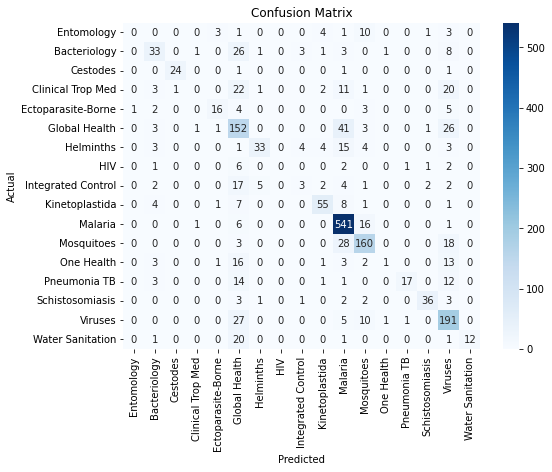

In [450]:
confusion_map(df, 'rf_preds', 'shortGenCat')

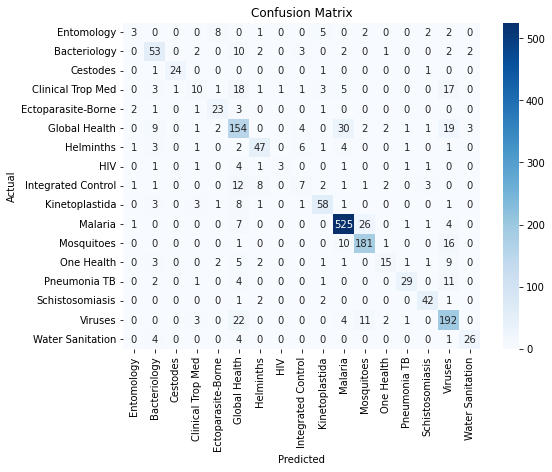

In [451]:
confusion_map(df, 'svm_preds', 'shortGenCat')

In [75]:
df.query('M')

UndefinedVariableError: name 'M' is not defined